# 土地銀行數位種子人才發展計劃

> 機器學習概念與行銷模型應用

[郭耀仁](https://hahow.in/@tonykuoyj) | <yaojenkuo@ntu.edu.tw>

## 目錄

- 機器學習基礎概念（P.3）
- 基礎分類模型與回歸模型（P.16）
- 個案實作：小組題目的問題分享（P.33）
- 分組討論：檢視各小組題目中機器學習模型的需求（P.65）
- 簡報預演（P.72）

## 機器學習基礎概念

## 機器學習的三個要素、一個但書

> A computer program is said to learn from experience E with respect to some class of tasks T and performance measure P if its performance at tasks in T, as measured by P, improves with experience E.

來源：[Machine Learning, Tom Mitchell, McGraw Hill, 1997](http://www.cs.cmu.edu/~tom/mlbook.html)

## 傳統透過電腦程式解決問題的方式示意圖

![Imgur](https://i.imgur.com/3pojPXW.png?1)

來源：<https://www.coursera.org/learn/introduction-tensorflow>

## 給定規則 $w$ 以及資料 $X$，我們就可以定義出函數 $f$ 生成答案 $y$

\begin{equation}
y = f(X;w) = Xw
\end{equation}

## 以機器學習的電腦程式解決問題的方式示意圖

![Imgur](https://i.imgur.com/YunyLd7.png)

來源：<https://www.coursera.org/learn/introduction-tensorflow>

## 給定答案 $y$ 以及資料 $X$，機器學習的電腦程式在最小化損失函數 $J$ 的前提下生成規則 $w$，進而獲得預測 $\hat{y}$

\begin{equation}
\text{choose} \; w \in \{w^1, w^2, ..., w^n\} \\
\text{where} \; w \; \text{minimizes} \; J(w) \\
\text{subject to} \; \hat{y} = h(X; w) = Xw \\
\text{where} \; J(w) \; \text{measures the loss between} \; y \; \text{and} \; \hat{y} \\
\end{equation}

## 預測數值時最常見的損失函數 $J$

最小化均方誤差（Mean squared error）。

\begin{align}
\operatorname*{arg\,min}_w \;  J(w) =  \frac{1}{m} \sum_i^m (y_i - \hat{y_i})^2
\end{align}

## 預測類別時最常見的損失函數 $J$

最小化預測錯誤個數。

\begin{align}
\operatorname*{arg\,min}_w \; J(w) = \sum_j n(E_j) \text{ where } E_j \; \text{represents the occurrence of } y_j \neq \hat{y_j}
\end{align}

## 機器學習的資料表達：特徵矩陣與目標陣列

- 外型 `(m, n)` 的特徵矩陣 $X$
- 外型 `(m,)` 的目標陣列 $y$

In [1]:
import matplotlib.pyplot as plt

def plot_X_y():
    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_axes([0, 0, 1, 1])
    ax.axis('off')
    ax.axis('equal')
    # Draw features matrix
    ax.vlines(range(6), ymin=0, ymax=9, lw=1)
    ax.hlines(range(10), xmin=0, xmax=5, lw=1)
    font_prop = dict(size=12, family='monospace')
    ax.text(-1, -1, "Feature Matrix ($X$)", size=14)
    ax.text(0.1, -0.3, r'n_features $\longrightarrow$', **font_prop)
    ax.text(-0.1, 0.1, r'$\longleftarrow$ m_samples', rotation=90,
            va='top', ha='right', **font_prop)
    # Draw labels vector
    ax.vlines(range(8, 10), ymin=0, ymax=9, lw=1)
    ax.hlines(range(10), xmin=8, xmax=9, lw=1)
    ax.text(7, -1, "Target Array ($y$)", size=14)
    ax.text(7.9, 0.1, r'$\longleftarrow$ m_samples', rotation=90,
            va='top', ha='right', **font_prop)
    ax.set_ylim(10, -2)
    plt.show()

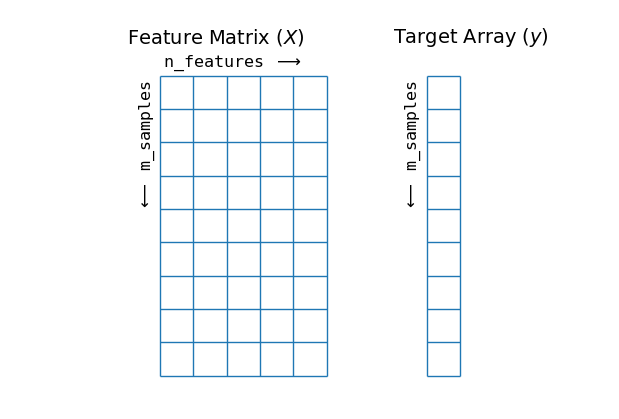

In [2]:
# 來源：<https://jakevdp.github.io/PythonDataScienceHandbook>
plot_X_y()

## 如何從 `DataFrame` 中擷取特徵矩陣與目標陣列

In [3]:
import pandas as pd

titanic_train = pd.read_csv("titanic_train.csv")
X = titanic_train["Age"].values.reshape(-1, 1) # select 1 column
y = titanic_train["Survived"].values           # select 1 column
print(X.shape)
print(y.shape)

(891, 1)
(891,)


In [4]:
X = titanic_train[["Age", "Sex"]].values # select 2 columns
y = titanic_train["Survived"].values     # select 1 column
print(X.shape)
print(y.shape)

(891, 2)
(891,)


In [5]:
house_prices_train = pd.read_csv("house_prices_train.csv")
X = house_prices_train["OverallQual"].values.reshape(-1, 1) # select 1 column
y = house_prices_train["SalePrice"].values                  # select 1 column
print(X.shape)
print(y.shape)

(1460, 1)
(1460,)


In [6]:
X = house_prices_train[["OverallQual", "OverallCond"]].values # select 2 columns
y = house_prices_train["SalePrice"].values                    # select 1 column
print(X.shape)
print(y.shape)

(1460, 2)
(1460,)


## 基礎分類模型與回歸模型

## 什麼是 Scikit-Learn

> Scikit-learn 是 Python 機器學習的第三方模組，透過它可以進行監督式以及非監督式學習，提供了模型訓練、資料預處理、模型選擇以及模型評估等功能。

來源：<https://scikit-learn.org>

## 根據說明文件的範例載入

多數時候我們使用 Scikit-Learn 中的特定類別或函數，因此以 `from sklearn import FUNCTION/CLASS` 載入特定類別或函數，而非 `import sklearn`

來源：<https://scikit-learn.org/stable/getting_started.html>

## 為什麼選擇 Scikit-Learn

- 簡潔、一致且設計良善的應用程式介面設計，只要理解基礎用法和語法，就能延伸切換到其他的演算法或模型。
- 文件撰寫完整而豐富。
- 維護良善。

## Scikit-Learn 應用程式介面設計原則

1. 一致性。
2. 可檢查性。
3. 不擴增新類別。
4. 可組合性。
5. 合理預設參數。

## 轉換器與預測器是 Scikit-Learn 所創造最重要的兩種類別

1. **轉換器：用來預處理資料。**
2. 預測器：用來訓練模型、生成規則 $w$

## 使用 Scikit-Learn 轉換器的標準步驟

1. 準備欲轉換的特徵矩陣 $X$ 或目標陣列 $y$
2. 建立轉換器類別的物件。
3. 將欲轉換的特徵矩陣 $X$ 或目標陣列 $y$ 輸入 `object.fit_transform()`
4. 檢查轉換結果。

## 使用 Scikit-Learn 轉換器 `PolynomialFeatures`

生成一個指定次方數的特徵多項式矩陣。

In [7]:
from sklearn.preprocessing import PolynomialFeatures

X = titanic_train["Fare"].values.reshape(-1, 1)      # step 1
polynomial_features = PolynomialFeatures()           # step 2
X_transformed = polynomial_features.fit_transform(X) # step 3
print(X_transformed[:5])                             # step 4

[[1.00000000e+00 7.25000000e+00 5.25625000e+01]
 [1.00000000e+00 7.12833000e+01 5.08130886e+03]
 [1.00000000e+00 7.92500000e+00 6.28056250e+01]
 [1.00000000e+00 5.31000000e+01 2.81961000e+03]
 [1.00000000e+00 8.05000000e+00 6.48025000e+01]]


## 使用 Scikit-Learn 轉換器 `StandardScaler`

生成一個經過 z-score 標準化的特徵矩陣。

\begin{equation}
z = \frac{x - \mu}{\sigma}
\end{equation}

In [8]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()                     # step 2
X_transformed = standard_scaler.fit_transform(X)       # step 3
print(X_transformed[:5])                               # step 4

[[-0.50244517]
 [ 0.78684529]
 [-0.48885426]
 [ 0.42073024]
 [-0.48633742]]


## 轉換器與預測器是 Scikit-Learn 所創造最重要的兩種類別

1. 轉換器：用來預處理資料。
2. **預測器：用來訓練模型、生成規則 $w$**

## 使用 Scikit-Learn 預測器的標準步驟

1. 準備欲訓練預測的特徵矩陣 $X$  與目標陣列 $y$
2. 切割訓練與驗證資料。
3. 建立預測器類別的物件。
4. 將訓練特徵矩陣 $X^{train}$ 與目標陣列 $y^{train}$ 輸入 `predictor.fit()`
5. 將驗證特徵矩陣 $X^{valid}$ 輸入 `predictor.predict()` 獲得 $\hat{y}^{valid}$
6. 比對 $\hat{y}^{valid}$ 與 $y^{valid}$ 之間的差異

## 關於切割訓練與驗證資料

- 訓練資料：具有實際值或標籤的已實現歷史資料。
- 驗證資料：具有實際值或標籤的已實現歷史資料，但是在使用上偽裝成不具有實際值或標籤的待預測資料。
- 使用 `sklearn.model_selection` 的 `train_test_split()` 函數。
    - `test_size` 驗證資料比例。
    - `random_state` 觀測值洗牌的隨機種子。

In [9]:
from sklearn.model_selection import train_test_split

## 使用 Scikit-Learn 預測器 `LinearRegression`

In [10]:
from sklearn.linear_model import LinearRegression

X = house_prices_train["OverallQual"].values.reshape(-1, 1)                  # step 1
y = house_prices_train["SalePrice"].values                                   # step 1
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state=42) # step 2
linear_regression = LinearRegression()                                       # step 3
linear_regression.fit(X_train, y_train)                                      # step 4
y_hat = linear_regression.predict(X_valid)                                   # step 5
m = y_valid.size                                                             # step 6
mean_squared_error = ((y_valid - y_hat)**2).sum()/m                          # step 6

## 使用 Scikit-Learn 預測器 `LogisticRegression`

In [11]:
from sklearn.linear_model import LogisticRegression

X = titanic_train[["Fare", "Parch"]].values                                  # step 1
y = titanic_train["Survived"].values                                         # step 1
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state=42) # step 2
logistic_regression = LogisticRegression()                                   # step 3
logistic_regression.fit(X_train, y_train)                                    # step 4
y_hat = logistic_regression.predict(X_valid)                                 # step 5
number_of_misclassification = (y_valid != y_hat).sum()                       # step 6
print(number_of_misclassification)                                           # step 6

75


## 複習：Scikit-Learn 應用程式介面設計原則

- 一致性。
    - 每個轉換器類別都有 `fit_transform()` 方法。
    - 每個預測器類別都有 `fit()` 與 `predict()` 方法。
- 合理預設參數。
    - 每個轉換器、預測器都可以用預設參數建立物件。

## 複習：Scikit-Learn 應用程式介面設計原則（續）

可檢查性：每個轉換器或預測器都有屬性讓使用者檢視轉換或預測的規則。

In [12]:
print(polynomial_features.degree)
print(standard_scaler.mean_)
print(standard_scaler.scale_)
print(linear_regression.intercept_)
print(linear_regression.coef_)

2
[32.20420797]
[49.66553444]
-92743.83823399295
[44774.94887757]


## 個案實作：小組題目的討論分享

## 如何呈現分群結果

十萬個資料點，分成 12 群。

In [13]:
import numpy as np
import pandas as pd

m = 10000
feature_1 = np.random.randint(1, 5, size=m)
feature_2 = np.random.randint(1, 4, size=m)
df = pd.DataFrame()
df["feature_1"] = feature_1
df["feature_2"] = feature_2
df

,feature_1,feature_2
0,4,3
1,2,3
2,3,1
3,1,3
4,1,3
...,...,...
9995,4,2
9996,1,1
9997,4,1
9998,2,2


## 由於兩個變數都是離散型，所以資料點重複在同一點

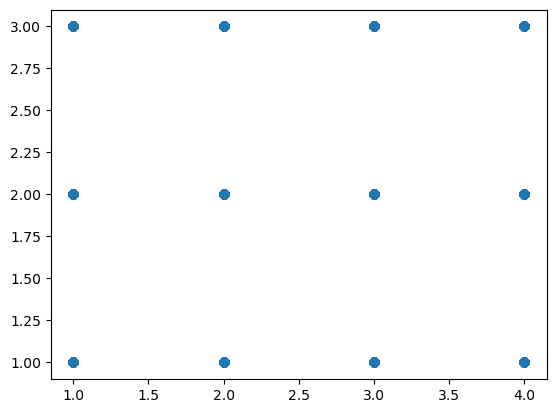

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.scatter(feature_1, feature_2)
plt.show()

## 加上隨機誤差讓資料不會全部相同

- `alpha` 透明度。
- `s` 資料點大小。

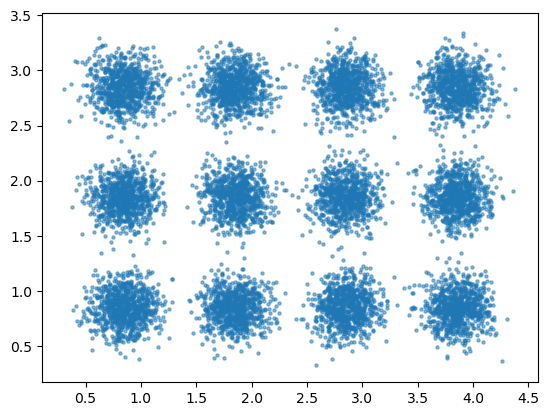

In [15]:
jitter_amount = 0.15
x_jittered = feature_1 + np.random.normal(-jitter_amount, jitter_amount, size=m)
y_jittered = feature_2 + np.random.normal(-jitter_amount, jitter_amount, size=m)
fig, ax = plt.subplots()
ax.scatter(x_jittered, y_jittered, alpha=0.5, s=5)
plt.show()

## 寬長資料的轉換

- 為什麼需要寬長資料的轉換：<https://en.wikipedia.org/wiki/Wide_and_narrow_data>
- 範例資料：<https://raw.githubusercontent.com/CSSEGISandData/COVID-19/refs/heads/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv>

In [16]:
import pandas as pd

wide_time_series = pd.read_csv("https://raw.githubusercontent.com/CSSEGISandData/COVID-19/refs/heads/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv")
print(wide_time_series.shape)
wide_time_series.head()

(289, 1147)


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288


In [17]:
long_time_series = pd.melt(wide_time_series, 
                           id_vars=["Province/State", "Country/Region", "Lat", "Long"],
                           var_name="Date", value_name="Confirmed")
print(long_time_series.shape)
long_time_series.head()

(330327, 6)


,Province/State,Country/Region,Lat,Long,Date,Confirmed
0,NaN,Afghanistan,33.93911,67.709953,1/22/20,0
1,NaN,Albania,41.15330,20.168300,1/22/20,0
2,NaN,Algeria,28.03390,1.659600,1/22/20,0
3,NaN,Andorra,42.50630,1.521800,1/22/20,0
4,NaN,Angola,-11.20270,17.873900,1/22/20,0


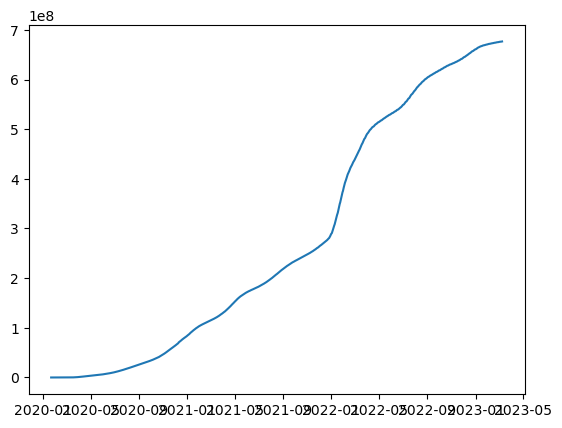

In [18]:
long_time_series["Date"] = pd.to_datetime(long_time_series["Date"], format="%m/%d/%y")
world_time_series = long_time_series.groupby("Date")["Confirmed"].sum().reset_index()
fig, ax = plt.subplots()
ax.plot(world_time_series["Date"], world_time_series["Confirmed"])
plt.show()

## 資料表的連結

- 所需的欄位在不同資料表中，透過可以對應的欄位（join key）來連結。
- 範例資料：
    - <https://raw.githubusercontent.com/CSSEGISandData/COVID-19/refs/heads/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv>
    - <https://raw.githubusercontent.com/CSSEGISandData/COVID-19/refs/heads/master/csse_covid_19_data/UID_ISO_FIPS_LookUp_Table.csv>

In [19]:
lookup_table = pd.read_csv("https://raw.githubusercontent.com/CSSEGISandData/COVID-19/refs/heads/master/csse_covid_19_data/UID_ISO_FIPS_LookUp_Table.csv")
print(lookup_table.shape)
print(wide_time_series.shape)
print(lookup_table.columns)
print(wide_time_series.columns)

(4321, 12)
(289, 1147)
Index(['UID', 'iso2', 'iso3', 'code3', 'FIPS', 'Admin2', 'Province_State',
       'Country_Region', 'Lat', 'Long_', 'Combined_Key', 'Population'],
      dtype='object')
Index(['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20', '1/23/20',
       '1/24/20', '1/25/20', '1/26/20', '1/27/20',
       ...
       '2/28/23', '3/1/23', '3/2/23', '3/3/23', '3/4/23', '3/5/23', '3/6/23',
       '3/7/23', '3/8/23', '3/9/23'],
      dtype='object', length=1147)


In [20]:
merged = pd.merge(lookup_table, wide_time_series,
                  left_on=["Province_State", "Country_Region"],
                  right_on=["Province/State", "Country/Region"],
                  how="right")
print(merged.shape)
merged.head()

(289, 1159)


,UID,iso2,iso3,code3,FIPS,Admin2,Province_State,Country_Region,Lat_x,Long_,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,4.0,AF,AFG,4.0,NaN,NaN,NaN,Afghanistan,33.93911,67.709953,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,8.0,AL,ALB,8.0,NaN,NaN,NaN,Albania,41.15330,20.168300,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
2,12.0,DZ,DZA,12.0,NaN,NaN,NaN,Algeria,28.03390,1.659600,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
3,20.0,AD,AND,20.0,NaN,NaN,NaN,Andorra,42.50630,1.521800,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
4,24.0,AO,AGO,24.0,NaN,NaN,NaN,Angola,-11.20270,17.873900,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288


## 如何比較、判斷差異

- 數值 vs. 數值。
- 數值 vs. 類別。
- 類別 vs. 類別。

## 數值 vs. 數值

計算相關係數（Pearson Correlation Coefficient）。

| 相關係數絕對值|關聯強弱程度|
| :--- | :--- |
| 0.00 ～ 0.25 | 極弱 / 無相關 |
| 0.25 ～ 0.50 | 弱相關 |
| 0.50 ～ 0.75 | 中度相關 |
| 0.75 ～ 1.00 | 高度相關 |

## 數值 vs. 數值：範例

In [21]:
select_numeric_columns = house_prices_train.select_dtypes(include="number")
corr_matrix = select_numeric_columns.corr()
corr_matrix_sale_price = corr_matrix["SalePrice"]
corr_matrix_sale_price[corr_matrix_sale_price.map(abs) > 0.25].sort_values()

LotArea         0.263843
HalfBath        0.284108
OpenPorchSF     0.315856
2ndFlrSF        0.319334
WoodDeckSF      0.324413
LotFrontage     0.351799
BsmtFinSF1      0.386420
Fireplaces      0.466929
MasVnrArea      0.477493
GarageYrBlt     0.486362
YearRemodAdd    0.507101
YearBuilt       0.522897
TotRmsAbvGrd    0.533723
FullBath        0.560664
1stFlrSF        0.605852
TotalBsmtSF     0.613581
GarageArea      0.623431
GarageCars      0.640409
GrLivArea       0.708624
OverallQual     0.790982
SalePrice       1.000000
Name: SalePrice, dtype: float64

## 數值 vs. 類別：平均值差異是否顯著

- 類別變數中的獨一值個數等於 2：
    - 獨立樣本 T 檢定（數值常態分佈）
    - Mann-Whitney U 檢定（數值為有序整數、不是常態分佈）
- 類別變數中的獨一值個數大於 2：
    - 單因子變異數分析（數值常態分佈）
    - Kruskal-Wallis 檢定（數值為有序整數、不是常態分佈）
- 若是顯著，可進一步透過計算 Effiect size 檢視強弱。

## 數值 vs. 類別：範例（類別變數中的獨一值個數等於 2）

In [22]:
y = titanic_train["Survived"].values
mean_age = titanic_train["Age"].mean()
x = titanic_train["Age"].fillna(mean_age).values
print(y[:5])
print(x[:5])

[0 1 1 1 0]
[22. 38. 26. 35. 35.]


In [23]:
titanic_train.groupby("Survived")["Age"].mean()

Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64

In [24]:
from scipy import stats

group_arrays = list()
for unique_elem in np.unique(y):
    group_arr = np.array([xi for xi, yi in zip(x, y) if yi == unique_elem])
    group_arrays.append(group_arr)

t_stat, p_value = stats.ttest_ind(*group_arrays)
if p_value < 0.05:
    print(f"{p_value:.4f} < 0.05, the difference between averages is significant.")
else:
    print(f"{p_value:.4f} >= 0.05, the difference between averages is not significant.")

0.0372 < 0.05, the difference between averages is significant.


## 顯著可進一步透過計算 Effiect size 檢視強弱

| Cohen's d|強弱程度|
| :--- | :--- |
| 0.0 ～ 0.2 | 極弱 |
| 0.2 ～ 0.5 | 弱 |
| 0.50 ～ 0.8 | 中 |
| 0.8 ～ | 強 |

In [25]:
def cohen_d(group1, group2):
    m1, m2 = np.mean(group1), np.mean(group2)
    n1, n2 = len(group1), len(group2)
    v1, v2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * v1 + (n2 - 1) * v2) / (n1 + n2 - 2))
    return (m1 - m2) / pooled_std

cohen_d_value = cohen_d(*group_arrays)

In [26]:
print(f"Cohen's d: {cohen_d_value:.4f}")
if cohen_d_value < 0.2:
    print("Very small Cohen's d.")
elif cohen_d_value < 0.5:
    print("Small Cohen's d.")
elif cohen_d_value < 0.5:
    print("Medium Cohen's d.")
else:
    print("Large Cohen's d.")

Cohen's d: 0.1437
Very small Cohen's d.


## 數值 vs. 類別：範例（類別變數中的獨一值個數大於 2）

In [27]:
x = house_prices_train["LotShape"].values
y = house_prices_train["SalePrice"].values
print(np.unique(x))
print(house_prices_train["LotShape"].value_counts())
print(y[:5])

['IR1' 'IR2' 'IR3' 'Reg']
LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64
[208500 181500 223500 140000 250000]


In [28]:
house_prices_train.groupby("LotShape")["SalePrice"].mean()

LotShape
IR1    206101.665289
IR2    239833.365854
IR3    216036.500000
Reg    164754.818378
Name: SalePrice, dtype: float64

In [29]:
group_arrays = list()
for unique_elem in np.unique(x):
    group_arr = np.array([yi for xi, yi in zip(x, y) if xi == unique_elem])
    group_arrays.append(group_arr)

f_statistic, p_value = stats.f_oneway(*group_arrays)
print(p_value)
if p_value < 0.05:
    print(f"{p_value:.4f} < 0.05, the difference between averages is significant.")
else:
    print(f"{p_value:.4f} >= 0.05, the difference between averages is not significant.")

6.447523852011766e-25
0.0000 < 0.05, the difference between averages is significant.


In [30]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols("SalePrice ~ C(LotShape)", data=house_prices_train).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)
p_value = anova_table.iloc[0, 3]
print(p_value)
if p_value < 0.05:
    print(f"{p_value:.4f} < 0.05, the difference between averages is significant.")
else:
    print(f"{p_value:.4f} >= 0.05, the difference between averages is not significant.")

                   sum_sq      df          F        PR(>F)
C(LotShape)  7.032607e+11     3.0  40.132852  6.447524e-25
Residual     8.504651e+12  1456.0        NaN           NaN
6.447523852015706e-25
0.0000 < 0.05, the difference between averages is significant.


## 顯著可進一步透過計算 Effiect size 檢視強弱

| $\eta^2$|強弱程度|
| :--- | :--- |
| 0.00 ～ 0.06 | 弱 |
| 0.06 ～ 0.14 | 中 |
| 0.14 ～ | 強 |

In [31]:
def calculate_eta_squared(groups):
    all_data = np.concatenate(groups)
    grand_mean = np.mean(all_data)
    ss_total = np.sum((all_data - grand_mean)**2)
    ss_between = 0
    for g in groups:
        ss_between += len(g) * (np.mean(g) - grand_mean)**2
    return ss_between / ss_total

eta_sq = calculate_eta_squared(group_arrays)

In [32]:
print(f"Eta Squared: {eta_sq:.4f}")
if eta_sq < 0.06:
    print("Small eta squared.")
elif eta_sq < 0.14:
    print("Medium eta squared.")
else:
    print("Large eta squared.")

Eta Squared: 0.0764
Medium eta squared.


## 類別 vs. 類別：是否顯著

- 兩個類別變數中的獨一值個數皆等於 2：費雪精確性檢定。
- 否則採取卡方檢定。
- 若是顯著，可進一步透過計算 Effiect size 檢視強弱。

## 類別 vs. 類別：範例（兩個類別變數中的獨一值個數皆等於 2）

In [33]:
x = titanic_train["Sex"].values
y = titanic_train["Survived"].values
contingency_table = pd.crosstab(x, y)
print(np.unique(x).size)
print(np.unique(y).size)
print(contingency_table)

2
2
col_0     0    1
row_0           
female   81  233
male    468  109


In [34]:
res = stats.fisher_exact(contingency_table, alternative="two-sided")
p_value = res.pvalue
print(p_value)
if p_value < 0.05:
    print(f"{p_value:.4f} < 0.05, the difference between proportions is significant.")
else:
    print(f"{p_value:.4f} >= 0.05, the difference between proportions is not significant.")

6.463921564583144e-60
0.0000 < 0.05, the difference between proportions is significant.


## 顯著可進一步透過計算 Effiect size 檢視強弱

| $\phi$ 絕對值|強弱程度|
| :--- | :--- |
| 0.0 ～ 0.3 | 弱 |
| 0.3 ～ 0.5 | 中 |
| 0.5 ～ | 強 |

In [35]:
def calculate_phi(crosstab):
    a, b = crosstab[0]
    c, d = crosstab[1]
    numerator = (a * d) - (b * c)
    denominator = np.sqrt((a + b) * (c + d) * (a + c) * (b + d))
    return numerator / denominator if denominator != 0 else 0

phi = calculate_phi(contingency_table)
abs_phi = abs(phi)

In [36]:
print(f"phi coefficient: {phi:.4f}")
if abs_phi < 0.3:
    print("Small phi coefficient.")
elif abs_phi < 0.5:
    print("Medium phi coefficient.")
else:
    print("Large phi coefficient.")

phi coefficient: -0.5434
Large phi coefficient.


## 類別 vs. 類別：範例（泛用的卡方檢定）

In [37]:
x = titanic_train["Pclass"].values
y = titanic_train["Survived"].values
contingency_table = pd.crosstab(x, y)
print(np.unique(x).size)
print(np.unique(y).size)
print(contingency_table)

3
2
col_0    0    1
row_0          
1       80  136
2       97   87
3      372  119


In [38]:
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table, correction=False)
print(p_value)
if p_value < 0.05:
    print(f"{p_value:.4f} < 0.05, the difference between proportions is significant.")
else:
    print(f"{p_value:.4f} >= 0.05, the difference between proportions is not significant.")

4.549251711298793e-23
0.0000 < 0.05, the difference between proportions is significant.


## 顯著可進一步透過計算 Effiect size 檢視強弱

| Cramer's V |強弱程度|
| :--- | :--- |
| 0.0 ～ 0.3 | 弱 |
| 0.3 ～ 0.5 | 中 |
| 0.5 ～ | 強 |

In [39]:
from scipy.stats.contingency import association

cramer_v = association(contingency_table, method="cramer")
print(f"Cramer's V: {cramer_v:.4f}")
if abs_phi < 0.3:
    print("Small Cramer's V.")
elif abs_phi < 0.5:
    print("Medium Cramer's V.")
else:
    print("Large Cramer's V.")

Cramer's V: 0.3398
Large Cramer's V.


## 分組討論：檢視各小組題目中機器學習模型的需求

## 特徵工程需求盤點

- 是否有資料表連接（Concatenate/Join/Merge）的需求？
- 是否有衍生計算欄位的需求？
- 是否有標準化的需求？
- 是否有連續型數值轉換為離散型數值的需求？
- 是否有類別變數要加入建模的需求？
- 是否有變數相關矩陣（Correlation matrix）的需求？

## 建模需求盤點

- 監督式學習
    - 是否有預測連續值的需求？
    - 是否有預測機率、預測離散值的需求？
- 非監督式學習
    - 是否有分群的需求？
    - 是否有降維的需求？

## 問題解決（Problem solving）的檢核點

- 是否有使用「假說推論樹」後向推導出解題脈絡？
- 是否有討論出「反直覺、反經驗」的假說？
- 是否有提出業務的機會點或痛點作為問題來源？
- 是否有列出關鍵的決策者、利益關係人？
- 是否有列出問題解決的指標為何？
- 分析的結果能否對應到行動方案？
- 是否有列出問題、行動方案的限制為何？
- 是否有列出可以尋求的支持及資源？

## 資料科學框架（Data science pipeline）的檢核點

- 是否已經完成資料來源盤點？
- Wrangle(資料載入 Import、清理 Tidy、轉換型別或外型 Transform) 是否已經試做？
- Visualise 資料視覺化是否已經試做？
- Model 模型是否已經試做？
- Program 程式設計是否已經試做？
- Communicate 故事是否已經順過脈絡？

## 行動方案（Action plan）的檢核點

- 是否有預計的損益表？是否有人力天數的估算？
- 是否有衡量財務效益與行動難易度，辨識出財務效益高且行動難度低的方案？
- 是否有列出責任歸屬、時間表與具體步驟？

## 成果發表（Presentation）的檢核點

- 是否已經決定簡報人選？
- 投入與產出不必是 1:1，有沒有評估過小組的槓桿能力？
- 是否有掌握 80/20 法則？能否把握開頭的 2 分鐘？
- 是否暸解聽眾的偏好？
- 是否妥善運用亞里斯多德的溝通三要素？

## 簡報預演